1.00e+08 → 0.006
1.00e+11 → 1.880
1.00e+09 → 0.121
1.00e+10 → 0.455
1.00e+14 → 3.625
1.00e+16 → 3.800
1.00e+13 → 3.694
1.00e+15 → 3.709
1.00e+12 → 3.617


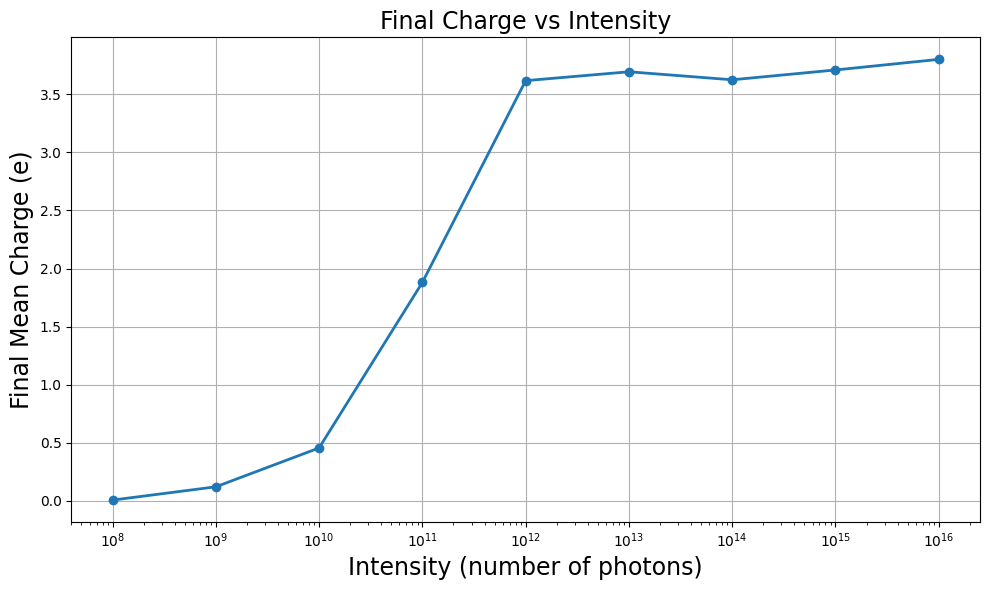

In [8]:
import numpy as np
import os
import matplotlib.pyplot as plt
simulation_folder = "../output_data/1perintensity"

# file location inside each run
act_path = os.path.join("simulation_output", "mean_charge_vs_time.txt")


# load mean charge vs time file 
def load_data(file_path):
    data = []
    with open(file_path) as f:
        for line in f:
            if line.startswith("#") or line.strip() == "":
                continue
            data.append([float(x) for x in line.split()])
    return np.array(data)


# get final charge from mean charge vs time
def get_final_charge(run_path):
    file_path = os.path.join(run_path, act_path)

    if not os.path.exists(file_path):
        print(f"Missing: {file_path}")
        return None

    data = load_data(file_path)

    if len(data) == 0:
        print(f"Empty: {file_path}")
        return None

    return data[-1, 1]  # last time point, mean charge
def main():
    intensities = []
    mean_charges = []

    for run_name in os.listdir(simulation_folder):
        run_path = os.path.join(simulation_folder, run_name)

        if not os.path.isdir(run_path):
            continue

        if not run_name.startswith("I_"):
            continue

        try:
            intensity = float(run_name.split("_")[1])
        except:
            print(f"Skipping bad folder: {run_name}")
            continue

        charges = []

      
        for replica in os.listdir(run_path):
            rep_path = os.path.join(run_path, replica)

            if not os.path.isdir(rep_path):
                continue

            charge = get_final_charge(rep_path)

            if charge is not None:
                charges.append(charge)

        if len(charges) == 0:
            print(f"No valid replicas for {run_name}")
            continue

        charges = np.array(charges)

        mean = np.mean(charges)
    

        intensities.append(intensity)
        mean_charges.append(mean)


        print(f"{intensity:.2e} → {mean:.3f}")

    # sort
    pairs = sorted(zip(intensities, mean_charges))
    intensities, mean_charges = zip(*pairs)

    # plot
    plt.figure(figsize=(10, 6))
    plt.plot(intensities, mean_charges, 'o-',linewidth=2)
    plt.xlabel("Intensity (number of photons)", fontsize=17)
    plt.ylabel("Final Mean Charge (e)", fontsize=17)
    plt.title("Final Charge vs Intensity", fontsize=17)

    plt.xscale("log")
    plt.grid()
    plt.tight_layout()
    plt.show()
main()
